# Week 8 Lab — SOLUTIONS — GJR, EGARCH, t Errors, Volatility Forecasts and VaR

**MANG2074 Financial Econometrics 1**

**Objectives**

- Estimate asymmetric volatility models (GJR-GARCH, EGARCH) and test for leverage effects.
- Estimate GARCH with Student-t errors and interpret the degrees of freedom.
- Produce fixed-window out-of-sample volatility forecasts.
- Compute a 1% one-day parametric VaR from a GARCH forecast.

**Data**

- `../data/currencies.csv` — daily `EUR`, `GBP`, `JPY` dollar rates, 1998–2018.
- `../data/sp500.csv` — daily S&P 500, 1950–2018.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

fx = pd.read_csv('../data/currencies.csv', index_col=0, parse_dates=True)
rets = pd.DataFrame({cur: 100 * np.log(fx[cur]).diff() for cur in ['EUR', 'GBP', 'JPY']}).dropna()

sp = pd.read_csv('../data/sp500.csv', index_col=0, parse_dates=True)
rsp = (100 * np.log(sp['sp500']).diff()).dropna()
print(rets.describe().round(3))

            EUR       GBP       JPY
count  7141.000  7141.000  7141.000
mean      0.000     0.003    -0.001
std       0.464     0.421     0.471
min      -3.457    -3.140    -3.664
25%      -0.197    -0.181    -0.208
50%       0.000     0.000     0.000
75%       0.202     0.183     0.206
max       2.523     6.352     2.850


## Task 1 — Three volatility models for the S&P 500

In [2]:
garch_sp = arch_model(rsp, p=1, q=1).fit(disp='off')
gjr_sp = arch_model(rsp, p=1, o=1, q=1).fit(disp='off')
egarch_sp = arch_model(rsp, vol='EGARCH', p=1, o=1, q=1).fit(disp='off')

print(gjr_sp.summary())

comp = pd.DataFrame({
    'loglik': [garch_sp.loglikelihood, gjr_sp.loglikelihood, egarch_sp.loglikelihood],
    'AIC': [garch_sp.aic, gjr_sp.aic, egarch_sp.aic],
    'BIC': [garch_sp.bic, gjr_sp.bic, egarch_sp.bic],
}, index=['GARCH(1,1)', 'GJR-GARCH', 'EGARCH'])
print(comp.round(1))


                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                  sp500   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -20467.0
Distribution:                  Normal   AIC:                           40944.1
Method:            Maximum Likelihood   BIC:                           40982.9
                                        No. Observations:                17246
Date:                Thu, Jun 11 2026   Df Residuals:                    17245
Time:                        01:25:31   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0331  5.925e-03      5.581  2.388e-08 [2.

**What to interpret.** Both asymmetric models beat plain GARCH decisively on log-likelihood, AIC and BIC — the asymmetry term is not a luxury for equities. In the GJR summary, note that the news coefficient $\alpha$ shrinks (≈0.03) once $\gamma$ (≈0.09) enters: much of what symmetric GARCH attributed to "news" is specifically *bad* news.

## Task 2 — Is there a leverage effect?

In [3]:
a, g = gjr_sp.params['alpha[1]'], gjr_sp.params['gamma[1]']
print(f"(a) GJR gamma = {g:.4f}, t = {gjr_sp.tvalues['gamma[1]']:.2f}, p = {gjr_sp.pvalues['gamma[1]']:.3g}")
print(f"(b) EGARCH gamma = {egarch_sp.params['gamma[1]']:.4f}, p = {egarch_sp.pvalues['gamma[1]']:.3g}")
print(f"(c) news impact on variance of a +1% shock: alpha           = {a:.4f}")
print(f"    news impact on variance of a -1% shock: alpha + gamma   = {a+g:.4f}")
print(f"    bad news moves variance {(a+g)/a:.1f} times as much as good news")


(a) GJR gamma = 0.0932, t = 5.56, p = 2.64e-08
(b) EGARCH gamma = -0.0713, p = 3.63e-10
(c) news impact on variance of a +1% shock: alpha           = 0.0324
    news impact on variance of a -1% shock: alpha + gamma   = 0.1257
    bad news moves variance 3.9 times as much as good news


**What to interpret.** (a) $\gamma \approx 0.09$ with a huge t-ratio: $H_0$ of symmetry is demolished — the **leverage effect** is real. (b) The EGARCH asymmetry coefficient is significantly *negative* (≈ −0.07): in EGARCH the term is $\gamma z_{t-1}$, so a negative shock ($z<0$) *raises* log-variance — the same economics with opposite sign convention. Read each model in its own parameterisation! (c) A −1% day moves next-day variance roughly **four times** as much as a +1% day ($\alpha+\gamma \approx 0.13$ vs $\alpha \approx 0.03$). Explanations: mechanical leverage (equity falls ⇒ debt/equity rises ⇒ riskier equity) and volatility-feedback/risk-aversion effects.

## Task 3 — Leverage in FX?

In [4]:
gjr_jpy = arch_model(rets['JPY'], p=1, o=1, q=1).fit(disp='off')
print(gjr_jpy.summary().tables[2] if False else gjr_jpy.params.round(4))
print(f"\ngamma: {gjr_jpy.params['gamma[1]']:.4f}, t = {gjr_jpy.tvalues['gamma[1]']:.2f}, p = {gjr_jpy.pvalues['gamma[1]']:.4f}")


mu          0.0036
omega       0.0020
alpha[1]    0.0268
gamma[1]    0.0254
beta[1]     0.9520
Name: params, dtype: float64

gamma: 0.0254, t = 2.30, p = 0.0213


**What to interpret.** For the yen $\gamma \approx 0.025$ — statistically significant (p ≈ 0.02) but barely a quarter of the S&P value. There is no "leverage" story for a currency: an exchange rate is a *relative* price of two monies, and what counts as "bad news" depends which side you sit on. The small positive $\gamma$ here (volatility rises slightly more when the dollar weakens against the yen) is usually read as a *safe-haven/carry-unwind* effect: yen appreciation episodes coincide with global risk-off. Moral: import the model, not the equity interpretation.

## Task 4 — Student-t errors for the yen

In [5]:
gjpy_n = arch_model(rets['JPY'], p=1, q=1).fit(disp='off')
gjpy_t = arch_model(rets['JPY'], p=1, q=1, dist='t').fit(disp='off')

print(gjpy_t.summary())
print(f"\nlog-likelihood: normal = {gjpy_n.loglikelihood:.1f}, Student-t = {gjpy_t.loglikelihood:.1f}")
print(f"estimated degrees of freedom nu = {gjpy_t.params['nu']:.2f}")


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          JPY   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3812.48
Distribution:      Standardized Student's t   AIC:                           7634.96
Method:                  Maximum Likelihood   BIC:                           7669.33
                                              No. Observations:                 7141
Date:                      Thu, Jun 11 2026   Df Residuals:                     7140
Time:                              01:25:31   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

**What to interpret.** The likelihood jumps by several hundred points for one extra parameter — overwhelming evidence for fat-tailed innovations. $\hat\nu \approx 3.1$ is *extremely* heavy-tailed (variance barely exists; the fourth moment does not): conditional on today's volatility, the yen can still jump violently. This is exactly the Week 7 finding (standardised residuals stayed leptokurtic) given a parametric answer — and it will widen the VaR materially in Task 7.

## Task 5 — Conditional volatility plots

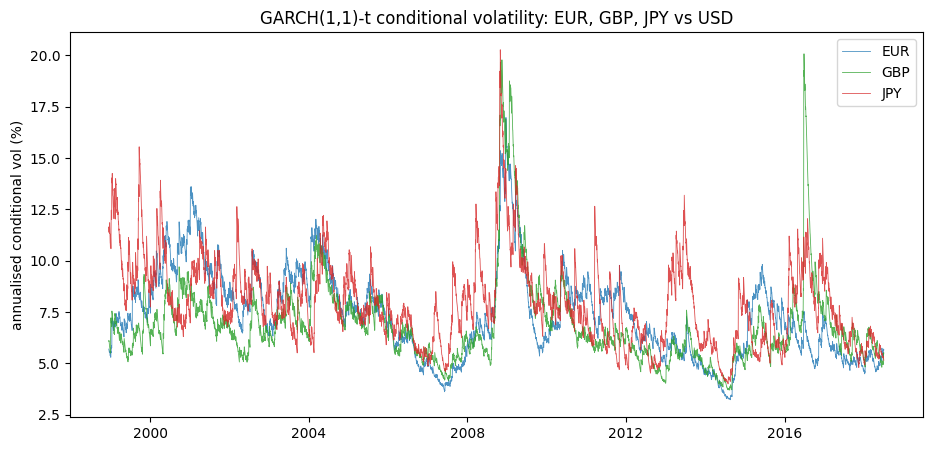

In [6]:
fig = plt.figure(figsize=(11, 5))
for cur, colr in [('EUR', 'tab:blue'), ('GBP', 'tab:green'), ('JPY', 'tab:red')]:
    res = arch_model(rets[cur], p=1, q=1, dist='t').fit(disp='off')
    ann_vol = np.sqrt(252) * res.conditional_volatility
    plt.plot(ann_vol, lw=0.6, color=colr, label=cur, alpha=0.8)
plt.legend(); plt.ylabel('annualised conditional vol (%)')
plt.title('GARCH(1,1)-t conditional volatility: EUR, GBP, JPY vs USD')
plt.show()


**What to interpret.** All three currencies spike together in late 2008 (annualised vol 20%+) — volatility is strongly correlated across markets in crises, which is when diversification fails. Currency-specific episodes stand out: the yen in 1998 (LTCM/carry unwind) and sterling around June 2016 (the Brexit referendum, where GBP vol dwarfs the others). Baseline FX vol of 5–10% annualised is far below equities — but tail risk per unit of vol is worse (Task 4).

## Task 6 — Fixed-window volatility forecasts

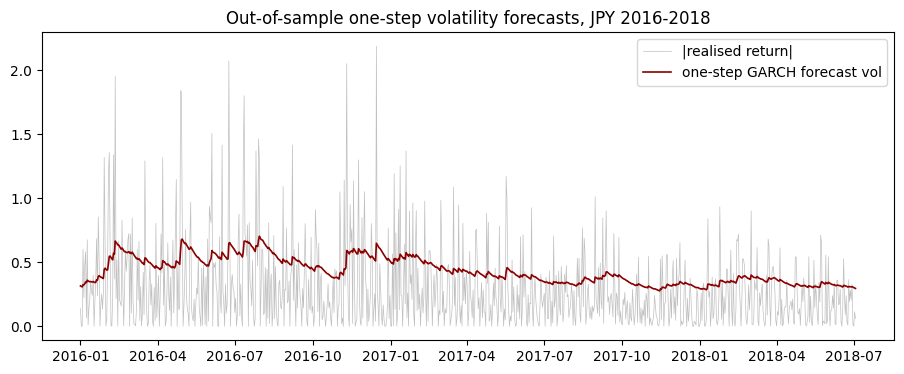

correlation(forecast vol, |realised|) = 0.320


In [7]:
am = arch_model(rets['JPY'], p=1, q=1)
res_fixed = am.fit(last_obs='2016-01-01', disp='off')   # estimation stops at end-2015

fc = res_fixed.forecast(horizon=1, start='2016-01-01', reindex=False)
fc_vol = np.sqrt(fc.variance['h.1'])

realised = rets['JPY']['2016-01-01':].abs()

plt.figure(figsize=(11, 4))
plt.plot(realised, lw=0.5, color='silver', label='|realised return|')
plt.plot(fc_vol, lw=1.2, color='darkred', label='one-step GARCH forecast vol')
plt.legend(); plt.title('Out-of-sample one-step volatility forecasts, JPY 2016-2018')
plt.show()

print(f"correlation(forecast vol, |realised|) = {fc_vol.corr(realised):.3f}")


**What to interpret.** The parameters were frozen at end-2015, so these are genuine out-of-sample forecasts. The forecast rises into the turbulent first half of 2016 (China scare, Brexit) and decays through the calm of 2017 — visibly tracking the clustering. The correlation with |realised returns| (~0.2–0.3) looks modest, but remember a single day's |return| is an extremely noisy proxy for that day's true volatility; against smoother realised-vol measures GARCH forecasts perform much better.

## Task 7 — 1% one-day parametric VaR

In [8]:
position = 1_000_000   # GBP value of the long-yen position

f1 = gjpy_t.forecast(horizon=1, reindex=False)
sigma_fc = float(np.sqrt(f1.variance.values[-1, 0]))   # tomorrow's vol, in %
mu = gjpy_t.params['mu']
nu = gjpy_t.params['nu']

q_norm = stats.norm.ppf(0.01)                          # -2.326
q_t = stats.t.ppf(0.01, nu) * np.sqrt((nu - 2) / nu)   # standardised-t 1% quantile

var_norm = -(mu + q_norm * sigma_fc) * position / 100
var_t    = -(mu + q_t   * sigma_fc) * position / 100

print(f"forecast one-day vol           = {sigma_fc:.4f} %")
print(f"1% quantile: normal = {q_norm:.3f},  standardised t({nu:.1f}) = {q_t:.3f}")
print(f"1% one-day VaR (normal)        = GBP {var_norm:,.0f}")
print(f"1% one-day VaR (Student-t)     = GBP {var_t:,.0f}")
print(f"t-based VaR is {var_t/var_norm - 1:+.1%} larger")


forecast one-day vol           = 0.3208 %
1% quantile: normal = -2.326,  standardised t(3.1) = -2.638
1% one-day VaR (normal)        = GBP 7,417
1% one-day VaR (Student-t)     = GBP 8,416
t-based VaR is +13.5% larger


**What to interpret.** Tomorrow's forecast vol is ~0.32% (a quiet end-of-sample regime), so the normal 1% VaR is roughly £7,400 per £1m, while the t(3.1) VaR is about £8,400 — ~13% larger, purely because the standardised t has a fatter 1% tail than the normal. Read it as: "we estimate only a 1-in-100 chance of losing more than ~£8,400 tomorrow on this position". Crucially this VaR is *conditional*: in October 2008 the same calculation would have produced a number several times larger. (At more extreme levels, e.g. 0.1%, the normal/t gap widens dramatically — normality is most dangerous exactly where VaR matters most.)

## Task 8 — Risk report

**Equity desk:** deploy **GJR-GARCH (or EGARCH) with Student-t errors**. The asymmetry term is large and overwhelmingly significant (bad news moves S&P variance ~4× as much as good news), so a symmetric model under-forecasts volatility after sell-offs — precisely when risk control matters. **FX desk:** a plain **GARCH(1,1)-t** is adequate; asymmetry exists for the yen but is economically marginal, while the fat tails ($\hat\nu \approx 3$) are first-order — the distributional assumption matters more than the asymmetry term. On VaR: the 1% one-day VaR for £1m long yen is ≈£7.4k under normality and ≈£8.4k under t innovations; we recommend the t figure, since the normal model demonstrably understates tail mass and would produce too many VaR breaches in backtesting. All numbers are conditional on the current calm regime and should be recomputed daily as the GARCH forecast updates.